<a href="https://colab.research.google.com/github/kondapallijayasri739-glitch/projects_analysis/blob/main/Students_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
## Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [3]:
## Upload Dataset
from google.colab import files

uploaded = files.upload()
data = pd.read_csv(next(iter(uploaded)))

Saving StudentsPerformance (1).csv to StudentsPerformance (1).csv


In [4]:
## Display Dataset
print(data.head())
print(data.info())
print(data.describe())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

In [5]:
## Data Preprocessing
le = LabelEncoder()

data["gender"] = le.fit_transform(data["gender"])
data["race/ethnicity"] = le.fit_transform(data["race/ethnicity"])
data["parental level of education"] = le.fit_transform(data["parental level of education"])
data["lunch"] = le.fit_transform(data["lunch"])
data["test preparation course"] = le.fit_transform(data["test preparation course"])

In [6]:
## Feature Selection
X = data[[
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "reading score",
    "writing score"
]]

y = data["math score"]

In [7]:
## Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
## Train the Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [9]:
##Prediction
y_pred = model.predict(X_test)
print(y_pred)

[77.76       54.74       76.16       77.11       80.96       85.79
 65.46       54.42       73.7        53.03       53.7        37.805
 67.52       51.39       84.95       71.28       48.99       47.43
 48.2        51.36       75.02       45.4        63.89       36.56
 78.41       86.07       71.5        46.64       36.85       50.75
 63.58       68.86       62.74       77.04       84.17       47.91
 76.22       70.42       70.11       16.24       79.44       66.46
 70.3        60.07       87.71       62.02       69.02       23.10333333
 92.02       65.85       75.31       72.27       78.53       48.03
 65.66       67.99       88.61       58.98       83.73       84.16
 55.67       73.12       66.77       54.         92.85       62.73
 60.76       54.71       60.95       86.45       73.92       82.79
 60.58       50.32       60.51       81.9        86.47       66.72
 56.59       54.93       63.26       42.23333333 79.94       67.8
 75.98       54.61       68.39       63.52       73.24  

In [11]:
##Accuracy
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 4.70082380952381


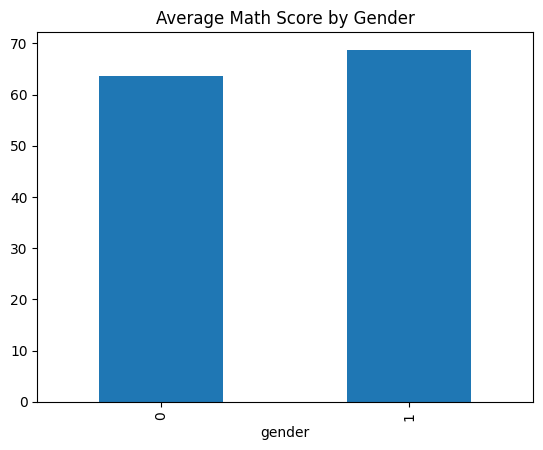

In [13]:
##Bar Graph(gender)
data.groupby("gender")["math score"].mean().plot(kind="bar")
plt.title("Average Math Score by Gender")
plt.show()

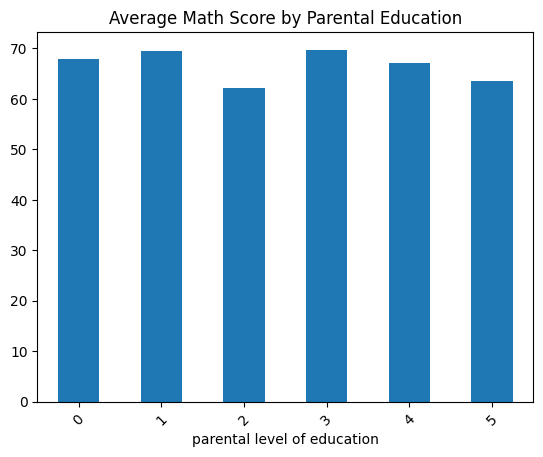

In [14]:
##Bar Graph (Parental Education)
data.groupby("parental level of education")["math score"].mean().plot(kind="bar")
plt.title("Average Math Score by Parental Education")
plt.xticks(rotation=45)
plt.show()

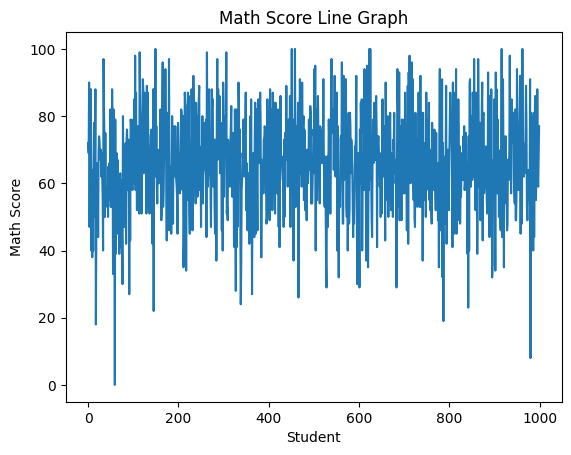

In [15]:
##Line Graph
plt.plot(data["math score"])
plt.title("Math Score Line Graph")
plt.xlabel("Student")
plt.ylabel("Math Score")
plt.show()

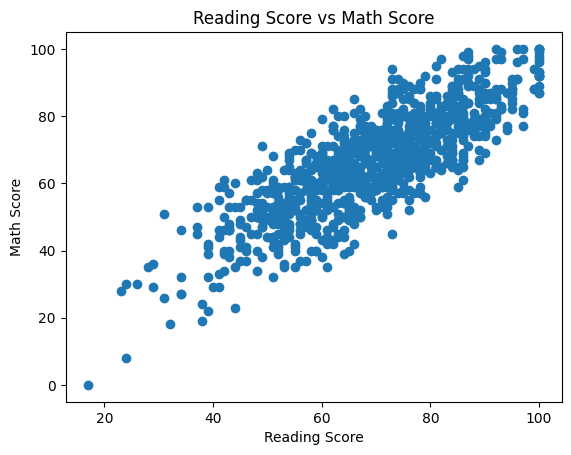

In [16]:
##Scatter Plot
plt.scatter(data["reading score"], data["math score"])
plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.show()